# 🌿 Deteksi Penyakit Daun — SVM dengan Perbandingan SMOTE vs Augmentasi Gambar

**Pendekatan:** Machine Learning klasik (tanpa deep learning)  
**Pipeline:** Pre-processing → Ekstraksi Fitur → SVM → Evaluasi  
**Tujuan:** Membandingkan dua strategi balancing kelas:
- **Eksperimen A** — SMOTE (balancing di ruang fitur)  
- **Eksperimen B** — Image Augmentation / Albumentations (balancing di ruang piksel)


## Cell 1 — Install & Import

In [ ]:
!pip install -q imbalanced-learn kagglehub albumentations

import os, cv2, time, warnings, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
from pathlib import Path
from collections import Counter
from joblib import Parallel, delayed, Memory

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing   import StandardScaler
from sklearn.svm             import SVC
from sklearn.metrics         import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition   import PCA

from skimage.feature import graycomatrix, graycoprops, hog, local_binary_pattern
from scipy.stats     import skew, kurtosis

import albumentations as A
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
print("Library siap")


✅ Library siap


## Cell 2 — Konfigurasi

In [ ]:
CONFIG = {
    'IMG_SIZE'    : 128,       # Ukuran gambar (pixel)
    'MAX_PER_CLASS': 300,      # Batas gambar asli per kelas
    'AUG_TARGET'  : 300,       # Target sampel per kelas (untuk augmentasi)
    'TEST_SIZE'   : 0.2,
    'RANDOM_STATE': 42,
    'SMOTE_K'     : 5,         # k-neighbors SMOTE
}
# Catatan: jumlah komponen PCA ditentukan otomatis di Cell 9
# menggunakan threshold 95% explained variance (bukan angka tetap)

print("⚙️  Konfigurasi:")
for k, v in CONFIG.items():
    print(f"   {k:<20}: {v}")
print("   PCA_COMPONENTS       : otomatis (95% explained variance — lihat Cell 9)")


⚙️  Konfigurasi:
   IMG_SIZE            : 128
   MAX_PER_CLASS       : 300
   AUG_TARGET          : 300
   TEST_SIZE           : 0.2
   RANDOM_STATE        : 42
   SMOTE_K             : 5
   PCA_COMPONENTS       : otomatis (95% explained variance — lihat Cell 9)


## Cell 3 — Download Dataset

In [ ]:
import kagglehub

path      = kagglehub.dataset_download("jawadali1045/20k-multi-class-crop-disease-images")
TRAIN_DIR = Path(path) / "Train"
print("Dataset:", path)
print("Train ada:", TRAIN_DIR.exists())


Using Colab cache for faster access to the '20k-multi-class-crop-disease-images' dataset.
📂 Dataset: /kaggle/input/20k-multi-class-crop-disease-images
✅ Train ada: True


## Cell 4 — Eksplorasi Dataset

Total kelas  : 42
Total gambar : 15,342
Min per kelas: 2
Max per kelas: 1640


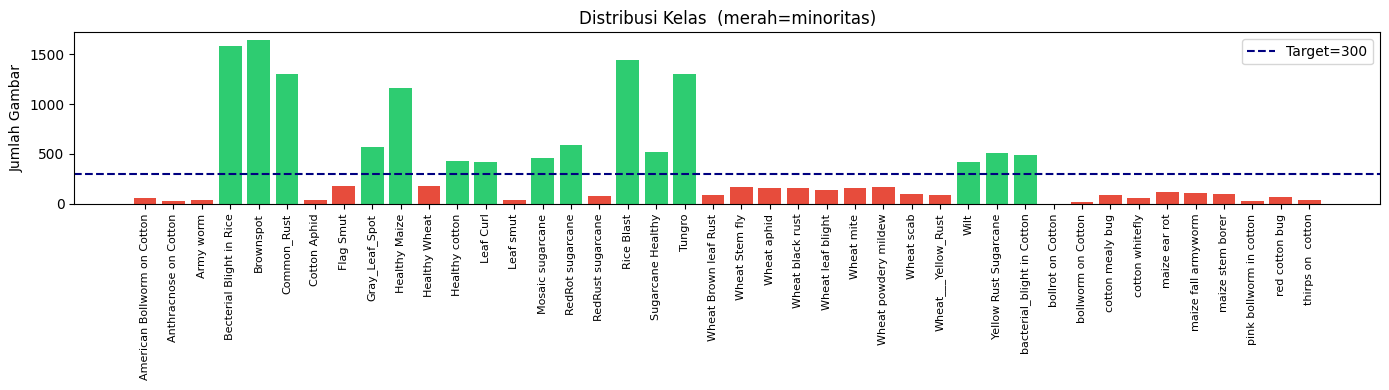

In [ ]:
class_names = sorted([f for f in os.listdir(TRAIN_DIR) if (TRAIN_DIR / f).is_dir()])
counts      = [len(os.listdir(TRAIN_DIR / c)) for c in class_names]

print(f"Total kelas  : {len(class_names)}")
print(f"Total gambar : {sum(counts):,}")
print(f"Min per kelas: {min(counts)}")
print(f"Max per kelas: {max(counts)}")

plt.figure(figsize=(14, 4))
colors = ['#e74c3c' if c < np.mean(counts)*0.6 else
          '#f39c12' if c < np.mean(counts) else '#2ecc71'
          for c in counts]
plt.bar(class_names, counts, color=colors)
plt.axhline(CONFIG['AUG_TARGET'], color='navy', linestyle='--', label=f"Target={CONFIG['AUG_TARGET']}")
plt.xticks(rotation=90, fontsize=8)
plt.ylabel("Jumlah Gambar")
plt.title("Distribusi Kelas  (merah=minoritas)")
plt.legend(); plt.tight_layout()
plt.savefig("distribusi_kelas.png", dpi=150, bbox_inches='tight')
plt.show()


## Cell 5 — Pre-processing

Pre-processing terdiri dari tiga langkah sederhana:

1. **Resize** → semua gambar diubah ke 128×128 piksel
2. **Bilateral Filter** → mengurangi noise sambil menjaga tepi daun
3. **CLAHE** → meningkatkan kontras di ruang warna LAB (channel L saja)

Tidak digunakan segmentasi kompleks agar pipeline tetap ringan dan stabil.


Mask coverage per sampel:
   American Bollworm on C:  99.4%  ███████████████████
   Anthracnose on Cotton :  30.1%  ██████
   Army worm             :  98.0%  ███████████████████
   Becterial Blight in Ri: 100.0%  ████████████████████
   Brownspot             :  92.7%  ██████████████████
   Common_Rust           :  79.9%  ███████████████
   Cotton Aphid          :  94.3%  ██████████████████
   Flag Smut             : 100.0%  ████████████████████


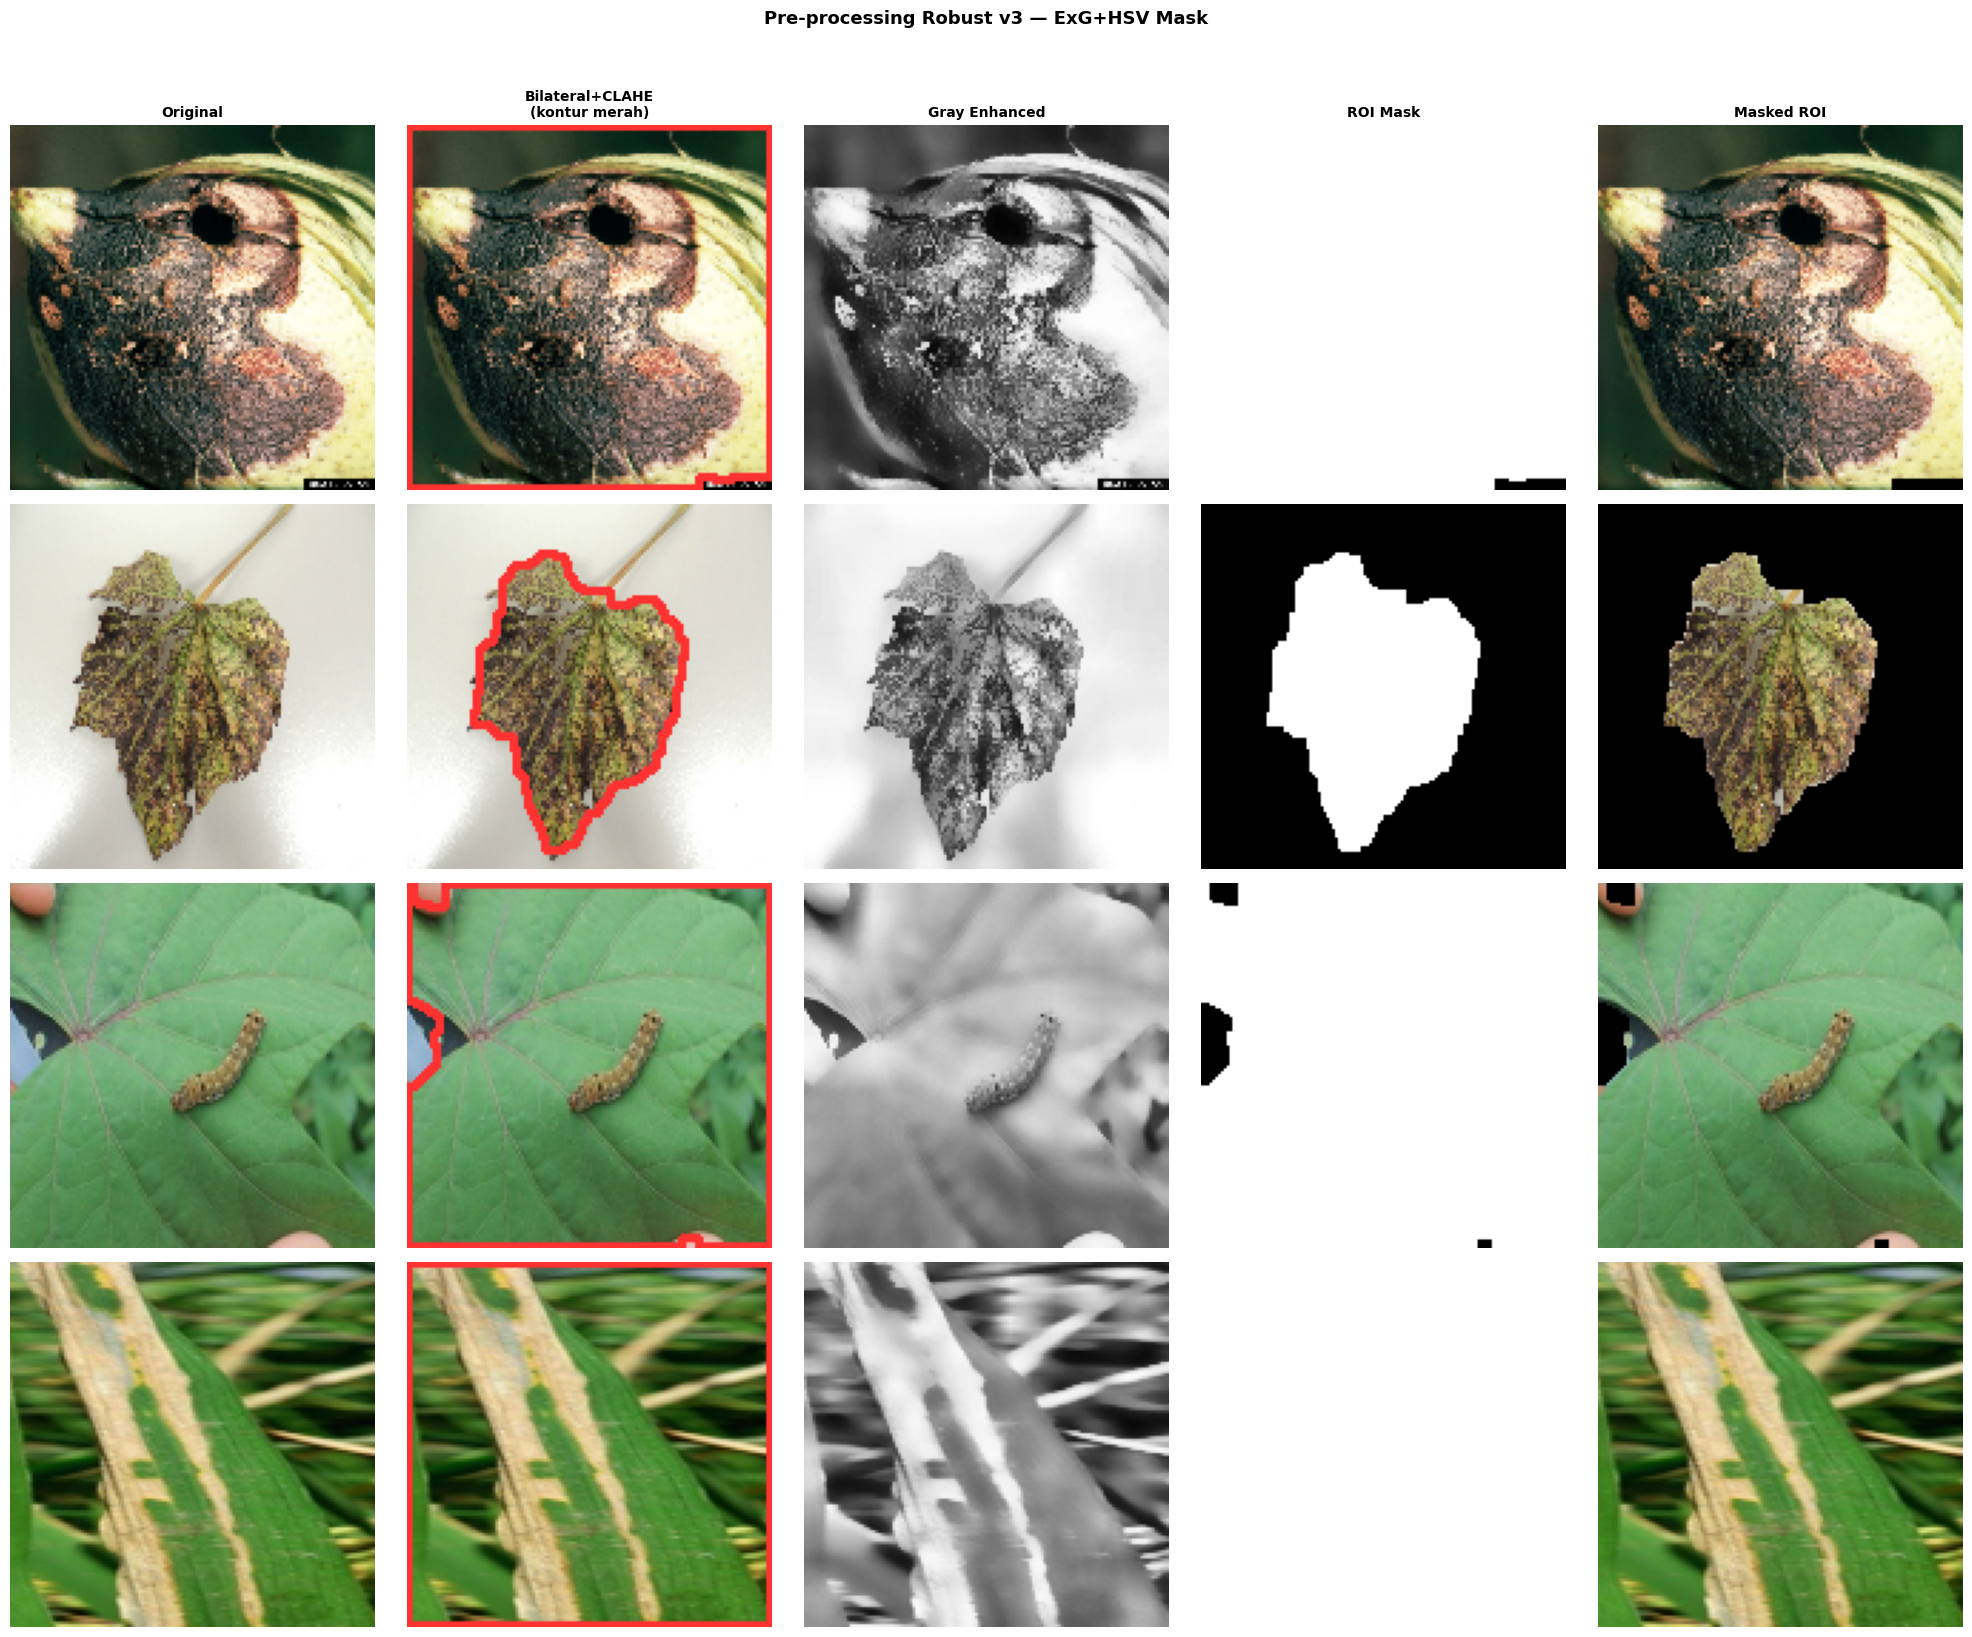

✅ preprocess_image() siap


In [ ]:
def preprocess_image(path_or_array, img_size):
    """
    Input : path gambar atau numpy array RGB
    Output: (img_rgb_orig, gray_clahe, roi_mask)
      - img_rgb_orig : gambar RGB asli yang di-resize
      - gray_clahe   : grayscale dengan CLAHE enhancement
      - roi_mask     : binary mask region daun
    """
    # --- Load ---
    if isinstance(path_or_array, (str, Path)):
        bgr = cv2.imread(str(path_or_array))
        if bgr is None:
            return None
        img_rgb_orig = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    else:
        img_rgb_orig = path_or_array.copy()

    # 1. Resize
    img_rgb_orig = cv2.resize(img_rgb_orig, (img_size, img_size))

    # 2. Bilateral filter (noise reduction, edge-preserving)
    img_bilateral = cv2.bilateralFilter(img_rgb_orig, d=9,
                                         sigmaColor=75, sigmaSpace=75)

    # 3. CLAHE pada channel L (LAB) untuk kontras
    lab           = cv2.cvtColor(img_bilateral, cv2.COLOR_RGB2LAB)
    clahe         = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0]  = clahe.apply(lab[:, :, 0])
    img_rgb_clahe = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    gray_clahe    = cv2.cvtColor(img_rgb_clahe, cv2.COLOR_RGB2GRAY)

    # 4. ExG Masking (Excess Green Index)
    img_float = img_rgb_orig.astype(np.float32) + 1e-7
    R, G, B   = img_float[:,:,0], img_float[:,:,1], img_float[:,:,2]
    exg       = (2*G - R - B) / (R + G + B)
    exg_norm  = cv2.normalize(exg, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, mask_exg = cv2.threshold(exg_norm, 0, 255,
                                 cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 5. HSV masking sebagai fallback (hijau, kuning, coklat/sakit)
    hsv     = cv2.cvtColor(img_rgb_orig, cv2.COLOR_RGB2HSV)
    mask_hsv = cv2.inRange(hsv,
                           np.array([10, 30, 30]),
                           np.array([90, 255, 255]))
    combined_mask = cv2.bitwise_or(mask_exg, mask_hsv)

    # 6. Morphological cleaning + ambil kontur terbesar
    kernel   = np.ones((5, 5), np.uint8)
    roi_mask = cv2.morphologyEx(combined_mask, cv2.MORPH_CLOSE, kernel)
    roi_mask = cv2.morphologyEx(roi_mask, cv2.MORPH_OPEN, kernel)
    contours, _ = cv2.findContours(roi_mask, cv2.RETR_EXTERNAL,
                                    cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest    = max(contours, key=cv2.contourArea)
        final_mask = np.zeros_like(roi_mask)
        cv2.drawContours(final_mask, [largest], -1, 255, -1)
        coverage = final_mask.sum() / 255 / (img_size ** 2)
        roi_mask = final_mask if coverage > 0.05 else np.ones_like(roi_mask) * 255
    else:
        roi_mask = np.ones_like(roi_mask) * 255

    return img_rgb_orig, gray_clahe, roi_mask


# --- Demo visual preprocessing (4 kelas, 5 kolom) ---
sample_classes = class_names[:4]
fig, axes = plt.subplots(len(sample_classes), 5,
                          figsize=(20, 4 * len(sample_classes)))
step_titles = ['Original', 'Bilateral+CLAHE\n(kontur merah)',
               'Gray Enhanced', 'ROI Mask', 'Masked ROI']

for row_idx, cls in enumerate(sample_classes):
    folder   = TRAIN_DIR / cls
    img_name = os.listdir(folder)[0]
    result   = preprocess_image(folder / img_name, CONFIG['IMG_SIZE'])
    if result is None:
        continue
    img_rgb, gray, roi_mask = result
    masked = cv2.bitwise_and(img_rgb, img_rgb, mask=roi_mask)
    contours, _ = cv2.findContours(roi_mask, cv2.RETR_EXTERNAL,
                                    cv2.CHAIN_APPROX_SIMPLE)
    overlay = img_rgb.copy()
    cv2.drawContours(overlay, contours, -1, (255, 50, 50), 2)
    imgs = [img_rgb, overlay,
            cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB),
            cv2.cvtColor(roi_mask, cv2.COLOR_GRAY2RGB), masked]
    for col_idx, img in enumerate(imgs):
        ax = axes[row_idx][col_idx]
        ax.imshow(img); ax.set_axis_off()
        if row_idx == 0:
            ax.set_title(step_titles[col_idx], fontsize=10, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(cls[:20], fontsize=9, rotation=0, labelpad=55, va='center')

# Coverage report
print('Mask coverage per sampel:')
for cls in class_names[:8]:
    folder   = TRAIN_DIR / cls
    img_name = os.listdir(folder)[0]
    r = preprocess_image(folder / img_name, CONFIG['IMG_SIZE'])
    if r:
        _, _, mask = r
        cov = mask.sum() / 255 / (CONFIG['IMG_SIZE']**2) * 100
        bar = chr(9608) * int(cov / 5)
        print(f'   {cls[:22]:22s}: {cov:5.1f}%  {bar}')

plt.suptitle('Pre-processing Robust v3 — ExG+HSV Mask',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('contoh_preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ preprocess_image() siap')


## Cell 6 — Ekstraksi Fitur

Tiga kelompok fitur klasik, kini dihitung **hanya pada area ROI mask** (region daun):

| Kelompok | Teknik | Keterangan |
|----------|--------|------------|
| Warna | Color Moments (HSV) | Mean, Std, Skewness tiap channel |
| Tekstur | GLCM on masked | Contrast, Correlation, Energy, Homogeneity |
| Bentuk/Tepi | HOG + LBP on masked | Dihitung hanya di area daun |


In [ ]:
def extract_features(img_rgb, gray, roi_mask):
    """
    Ekstrak fitur dari gambar yang sudah di-preprocess.
    Fitur GLCM, LBP, HOG dihitung pada area ROI mask (region daun).
    Mengembalikan vektor fitur 1D (float32).
    """
    feat = []

    # ── A. Color Moments (HSV) ─────────────────────────────────
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV).astype(np.float32)
    for ch in range(3):                         # H, S, V
        vals = hsv[:, :, ch].ravel()
        feat += [float(np.mean(vals)),
                 float(np.std(vals)),
                 float(skew(vals))]             # 3 nilai × 3 channel = 9

    # ── B. GLCM — dihitung pada region ROI mask ───────────────
    # Crop ke bounding box mask agar GLCM fokus ke area daun
    pts = cv2.findNonZero(roi_mask)
    if pts is not None:
        x, y, w, h = cv2.boundingRect(pts)
        w, h = max(w, 8), max(h, 8)
        gray_roi = gray[y:y+h, x:x+w]
    else:
        gray_roi = gray
    glcm = graycomatrix(gray_roi, distances=[1, 2], angles=[0, np.pi/2],
                        levels=256, symmetric=True, normed=True)
    for prop in ['contrast', 'correlation', 'energy', 'homogeneity']:
        feat += graycoprops(glcm, prop).flatten().tolist()  # 4 prop × 4 = 16

    # ── C. LBP — dihitung hanya pada piksel di dalam mask ─────
    lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
    lbp_masked = (lbp.ravel()[roi_mask.ravel() > 0]
                  if roi_mask.sum() > 100 else lbp.ravel())
    hist, _ = np.histogram(lbp_masked, bins=10, range=(0, 10), density=True)
    feat += hist.tolist()                                    # 10

    # ── D. HOG — dihitung pada gambar yang sudah di-mask ──────
    gray_masked = cv2.bitwise_and(gray, gray, mask=roi_mask)
    hog_feat = hog(gray_masked,
                   orientations=8,
                   pixels_per_cell=(16, 16),
                   cells_per_block=(2, 2),
                   feature_vector=True)
    feat += hog_feat.tolist()

    return np.array(feat, dtype=np.float32)


# Cek dimensi fitur
sample_path = TRAIN_DIR / class_names[0] / os.listdir(TRAIN_DIR / class_names[0])[0]
r = preprocess_image(sample_path, CONFIG['IMG_SIZE'])
test_feat = extract_features(*r)
print(f'✅ Dimensi vektor fitur: {test_feat.shape[0]}')
print(f'   - Color Moments (HSV) : 9')
print(f'   - GLCM on ROI         : 16')
print(f'   - LBP on ROI          : 10')
print(f'   - HOG on masked       : {test_feat.shape[0] - 35}')

✅ Dimensi vektor fitur: 1603
   - Color Moments (HSV) : 9
   - GLCM on ROI         : 16
   - LBP on ROI          : 10
   - HOG on masked       : 1568


## Cell 7 — Augmentasi Pipeline (untuk Eksperimen B)

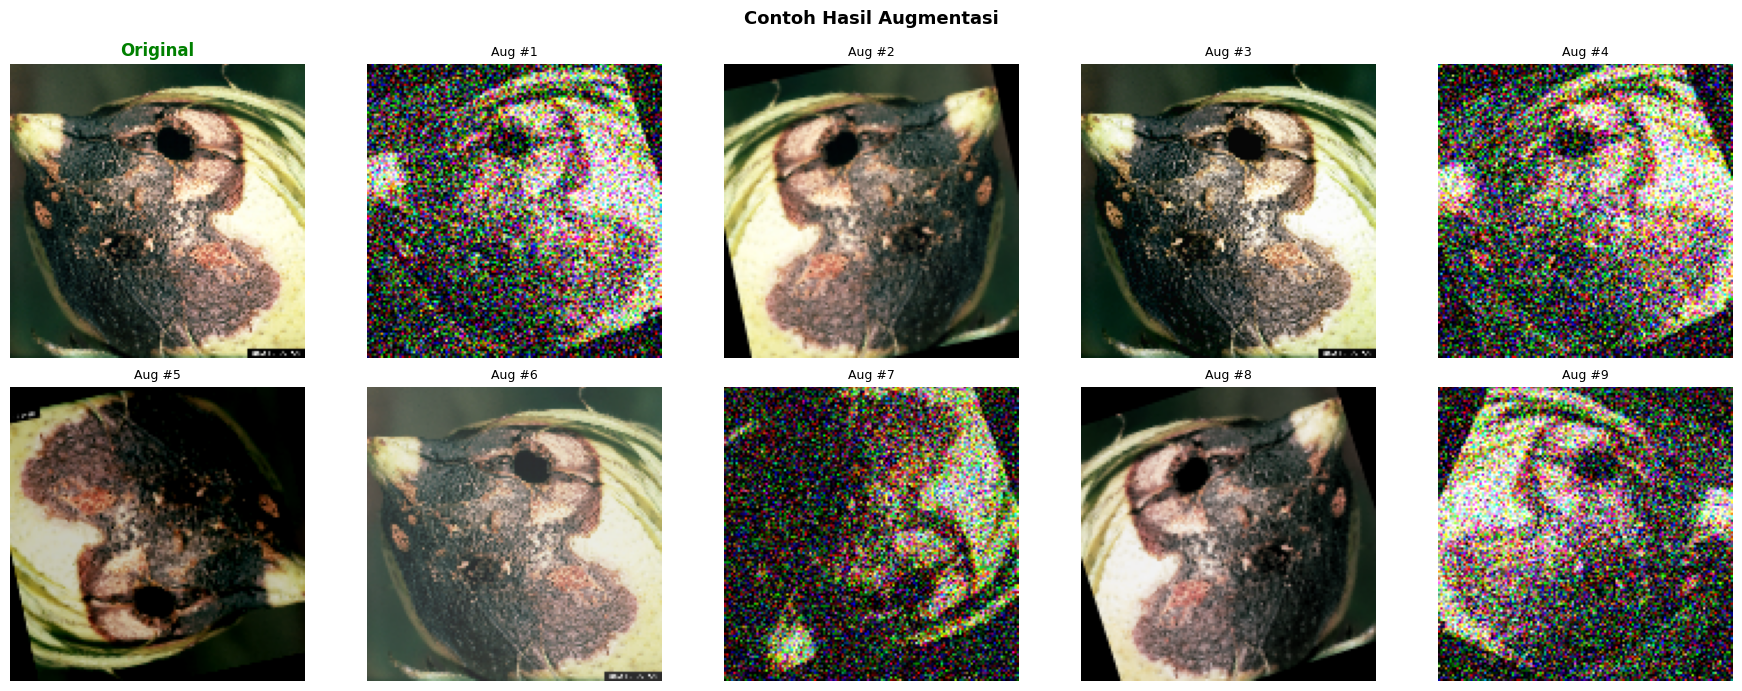

✅ Augmentasi pipeline siap


In [ ]:
aug_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=30, p=0.6),
    A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.6),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=25, val_shift_limit=15, p=0.5),
    A.GaussNoise(var_limit=(10, 40), p=0.3),
])

def augment(img_rgb, seed=None):
    if seed is not None:
        np.random.seed(seed)
    if img_rgb.dtype != np.uint8:
        img_rgb = (img_rgb * 255).clip(0, 255).astype(np.uint8)
    return aug_pipeline(image=img_rgb)['image']


# Demo augmentasi
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
bgr  = cv2.imread(str(sample_path))
orig = cv2.resize(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB), (CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE']))
axes[0, 0].imshow(orig); axes[0, 0].set_title("Original", color='green', fontweight='bold')
for i in range(1, 10):
    ax = axes[i // 5][i % 5]
    ax.imshow(augment(orig, seed=i*13)); ax.set_title(f"Aug #{i}", fontsize=9)
for ax in axes.ravel(): ax.axis('off')
plt.suptitle("Contoh Hasil Augmentasi", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("contoh_augmentasi.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Augmentasi pipeline siap")


## Cell 8 — Load & Ekstraksi Fitur Gambar Asli

In [ ]:
CACHE_DIR = '/content/feat_cache'
shutil.rmtree(CACHE_DIR, ignore_errors=True)
mem = Memory(CACHE_DIR, verbose=0)

@mem.cache
def _process_path(path_str, img_size):
    r = preprocess_image(path_str, img_size)
    if r is None:
        return None
    return extract_features(*r)


rng = np.random.default_rng(CONFIG['RANDOM_STATE'])

# Kumpulkan path per kelas
all_paths, all_labels = [], []
orig_imgs = {}                 # simpan gambar asli untuk augmentasi nanti

for cls in class_names:
    files = os.listdir(TRAIN_DIR / cls)
    rng.shuffle(files)
    files = files[:CONFIG['MAX_PER_CLASS']]
    for f in files:
        all_paths.append(str(TRAIN_DIR / cls / f))
        all_labels.append(cls)

print(f"📸 Total gambar asli: {len(all_paths):,}")
print("🔄 Ekstraksi fitur (paralel)...")
t0 = time.time()

results = Parallel(n_jobs=-1, backend='loky', verbose=3)(
    delayed(_process_path)(p, CONFIG['IMG_SIZE']) for p in all_paths
)

X_orig, y_orig, orig_imgs_per_cls = [], [], {c: [] for c in class_names}
needs_aug = {cls for cls, cnt in Counter(all_labels).items()
             if cnt < CONFIG['AUG_TARGET']}

for feat, label, path in zip(results, all_labels, all_paths):
    if feat is not None:
        X_orig.append(feat)
        y_orig.append(label)
        # Simpan gambar asli untuk kelas yang nanti perlu augmentasi
        if label in needs_aug and len(orig_imgs_per_cls[label]) < 60:
            bgr = cv2.imread(path)
            if bgr is not None:
                rgb = cv2.resize(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB),
                                 (CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE']))
                orig_imgs_per_cls[label].append(rgb)

X_orig = np.array(X_orig, dtype=np.float32)
y_orig = np.array(y_orig)
X_orig = np.nan_to_num(X_orig, nan=0.0, posinf=0.0, neginf=0.0)

print(f"\n Selesai dalam {time.time()-t0:.1f}s")
print(f" Shape X: {X_orig.shape}")
print(f"   Kelas perlu augmentasi: {len(needs_aug)}")


📸 Total gambar asli: 6,995
🔄 Ekstraksi fitur (paralel)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done 214 tasks      | elapsed:   19.4s
[Parallel(n_jobs=-1)]: Done 534 tasks      | elapsed:   41.5s
[Parallel(n_jobs=-1)]: Done 982 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 1558 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 2084 tasks      | elapsed:  2.9min
[Parallel(n_jobs=-1)]: Done 2916 tasks      | elapsed:  3.8min
[Parallel(n_jobs=-1)]: Done 3876 tasks      | elapsed:  4.6min
[Parallel(n_jobs=-1)]: Done 4840 tasks      | elapsed:  5.9min
[Parallel(n_jobs=-1)]: Done 5924 tasks      | elapsed:  6.9min
[Parallel(n_jobs=-1)]: Done 6995 out of 6995 | elapsed:  8.0min finished



✅ Selesai dalam 512.5s
📐 Shape X: (6994, 1603)
   Kelas perlu augmentasi: 27


---
## Eksperimen A — SMOTE

SMOTE membuat sampel sintetis dengan **interpolasi antar fitur** kelas minoritas.  
Dilakukan **setelah** ekstraksi fitur, hanya pada data training.


## Cell 9 — Scree Plot PCA (dijalankan sekali, dipakai kedua eksperimen)

Fit PCA tanpa batas komponen ke data training, lalu pilih jumlah komponen yang mencapai **95% explained variance**. Nilai ini (`N_PCA_95`) otomatis dipakai di Eksperimen A & B.

Total fitur         : 1603
Komponen untuk 90%  : 282
Komponen untuk 95%  : 405  ← yang akan dipakai


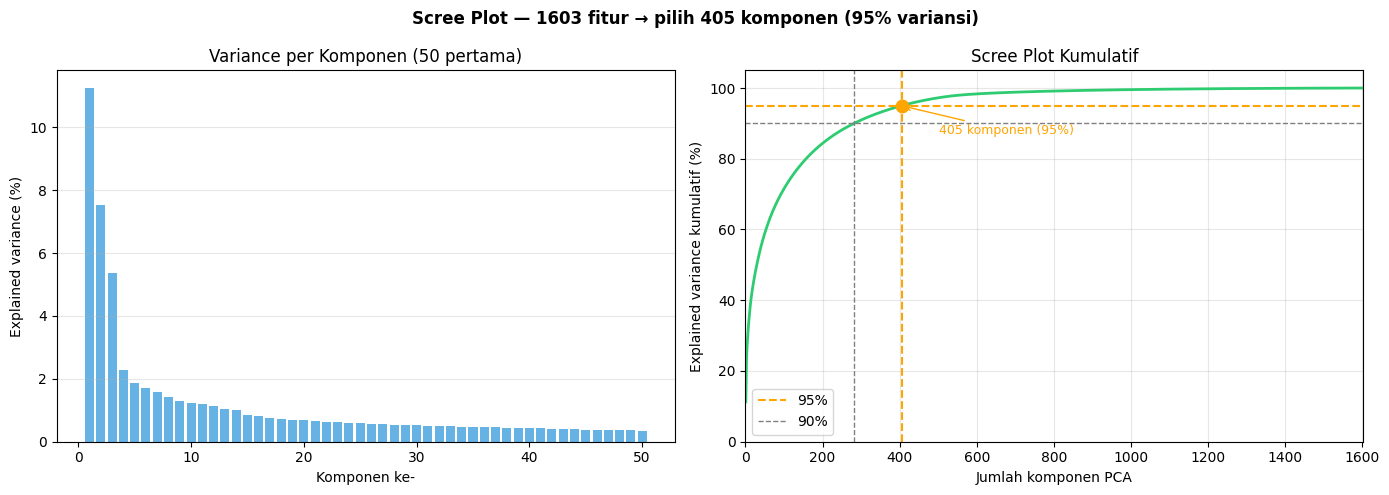


 N_PCA_95 = 405 siap dipakai di Eksperimen A dan B


In [ ]:
# =========================================================
# CELL 9 — Tentukan jumlah komponen PCA secara otomatis
# =========================================================

# Fit sementara untuk analisis (pakai data training sebelum SMOTE)
X_tr_tmp, _, _, _ = train_test_split(
    X_orig, y_orig, test_size=CONFIG['TEST_SIZE'],
    random_state=CONFIG['RANDOM_STATE'], stratify=y_orig
)
sc_tmp     = StandardScaler()
X_tr_tmp_s = sc_tmp.fit_transform(X_tr_tmp)

# Fit PCA tanpa batasan komponen
pca_full = PCA(random_state=CONFIG['RANDOM_STATE'])
pca_full.fit(X_tr_tmp_s)

cumvar   = np.cumsum(pca_full.explained_variance_ratio_) * 100
N_FITUR  = X_tr_tmp_s.shape[1]
N_PCA_95 = int(np.argmax(cumvar >= 95) + 1)   # ← nilai ini yang dipakai
N_PCA_90 = int(np.argmax(cumvar >= 90) + 1)

print(f'Total fitur         : {N_FITUR}')
print(f'Komponen untuk 90%  : {N_PCA_90}')
print(f'Komponen untuk 95%  : {N_PCA_95}  ← yang akan dipakai')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kiri: variance per komponen (50 pertama)
axes[0].bar(range(1, min(51, N_FITUR+1)),
            pca_full.explained_variance_ratio_[:50] * 100,
            color='#3498db', alpha=0.75)
axes[0].set_xlabel('Komponen ke-')
axes[0].set_ylabel('Explained variance (%)')
axes[0].set_title('Variance per Komponen (50 pertama)')
axes[0].grid(axis='y', alpha=0.3)

# Kanan: kumulatif + threshold
axes[1].plot(range(1, N_FITUR+1), cumvar, color='#2ecc71', linewidth=2)
axes[1].axhline(95, color='orange', linestyle='--', linewidth=1.5, label='95%')
axes[1].axhline(90, color='gray',   linestyle='--', linewidth=1,   label='90%')
axes[1].axvline(N_PCA_95, color='orange', linestyle='--', linewidth=1.5)
axes[1].axvline(N_PCA_90, color='gray',   linestyle='--', linewidth=1)
axes[1].scatter([N_PCA_95], [95], color='orange', s=80, zorder=5)
axes[1].annotate(
    f'{N_PCA_95} komponen (95%)',
    xy=(N_PCA_95, 95), xytext=(N_PCA_95 + max(N_FITUR*0.06, 3), 87),
    arrowprops=dict(arrowstyle='->', color='orange'),
    color='orange', fontsize=9
)
axes[1].set_xlabel('Jumlah komponen PCA')
axes[1].set_ylabel('Explained variance kumulatif (%)')
axes[1].set_title('Scree Plot Kumulatif')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, N_FITUR)
axes[1].set_ylim(0, 105)

plt.suptitle(f'Scree Plot — {N_FITUR} fitur → pilih {N_PCA_95} komponen (95% variansi)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n N_PCA_95 = {N_PCA_95} siap dipakai di Eksperimen A dan B')


In [ ]:
print("=" * 55)
print("  EKSPERIMEN A — SMOTE")
print("=" * 55)

# Split
X_tr_a, X_te_a, y_tr_a, y_te_a = train_test_split(
    X_orig, y_orig,
    test_size=CONFIG['TEST_SIZE'],
    random_state=CONFIG['RANDOM_STATE'],
    stratify=y_orig
)

# Normalisasi
sc_a       = StandardScaler()
X_tr_a_s   = sc_a.fit_transform(X_tr_a)
X_te_a_s   = sc_a.transform(X_te_a)

# SMOTE
cnt_before = Counter(y_tr_a)
min_samp   = min(cnt_before.values())
k          = min(CONFIG['SMOTE_K'], min_samp - 1) if min_samp > 1 else 1
smote      = SMOTE(random_state=CONFIG['RANDOM_STATE'], k_neighbors=k)
X_tr_a_s, y_tr_a = smote.fit_resample(X_tr_a_s, y_tr_a)
print(f"Sebelum SMOTE: {sum(cnt_before.values()):,} sampel")
print(f"Setelah SMOTE: {len(y_tr_a):,} sampel")

# PCA — pakai N_PCA_95 dari scree plot
pca_a    = PCA(n_components=N_PCA_95, random_state=CONFIG['RANDOM_STATE'])
X_tr_a_p = pca_a.fit_transform(X_tr_a_s)
X_te_a_p = pca_a.transform(X_te_a_s)
print(f"PCA: {N_PCA_95} komponen → {pca_a.explained_variance_ratio_.cumsum()[-1]*100:.1f}% variansi")
print(f"Shape Train: {X_tr_a_p.shape}  |  Test: {X_te_a_p.shape}")

# GridSearchCV
param_grid = {'C': [1, 10, 50], 'gamma': ['scale', 'auto'],
              'kernel': ['rbf'], 'class_weight': ['balanced']}
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=CONFIG['RANDOM_STATE'])
gs_a = GridSearchCV(SVC(probability=False, random_state=CONFIG['RANDOM_STATE']),
                    param_grid, cv=cv5, scoring='balanced_accuracy', n_jobs=-1, verbose=1)
print("\n🔍 GridSearchCV...")
t0 = time.time()
gs_a.fit(X_tr_a_p, y_tr_a)
print(f"Selesai {time.time()-t0:.1f}s  |  Best: {gs_a.best_params_}")
print(f"CV Balanced Acc: {gs_a.best_score_*100:.2f}%")


  EKSPERIMEN A — SMOTE
Sebelum SMOTE: 5,595 sampel
Setelah SMOTE: 10,080 sampel
PCA: 405 komponen → 95.5% variansi
Shape Train: (10080, 405)  |  Test: (1399, 405)

🔍 GridSearchCV...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Selesai 632.6s  |  Best: {'C': 50, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
CV Balanced Acc: 82.61%



  [A] Accuracy       : 56.90%
  [A] Balanced Acc   : 43.07%
  [A] F1 Macro       : 43.11%
  [A] CV ±std        : 83.22% ± 3.66%
                             precision    recall  f1-score   support

American Bollworm on Cotton       0.33      0.18      0.24        11
      Anthracnose on Cotton       0.00      0.00      0.00         6
                  Army worm       0.00      0.00      0.00         8
   Becterial Blight in Rice       0.51      0.80      0.62        60
                  Brownspot       0.63      0.78      0.70        60
                Common_Rust       0.89      0.78      0.83        60
               Cotton Aphid       0.00      0.00      0.00         8
                  Flag Smut       0.74      0.81      0.77        36
             Gray_Leaf_Spot       0.67      0.85      0.75        60
              Healthy Maize       0.69      0.70      0.69        60
              Healthy Wheat       0.80      0.56      0.66        36
             Healthy cotton       0.70    

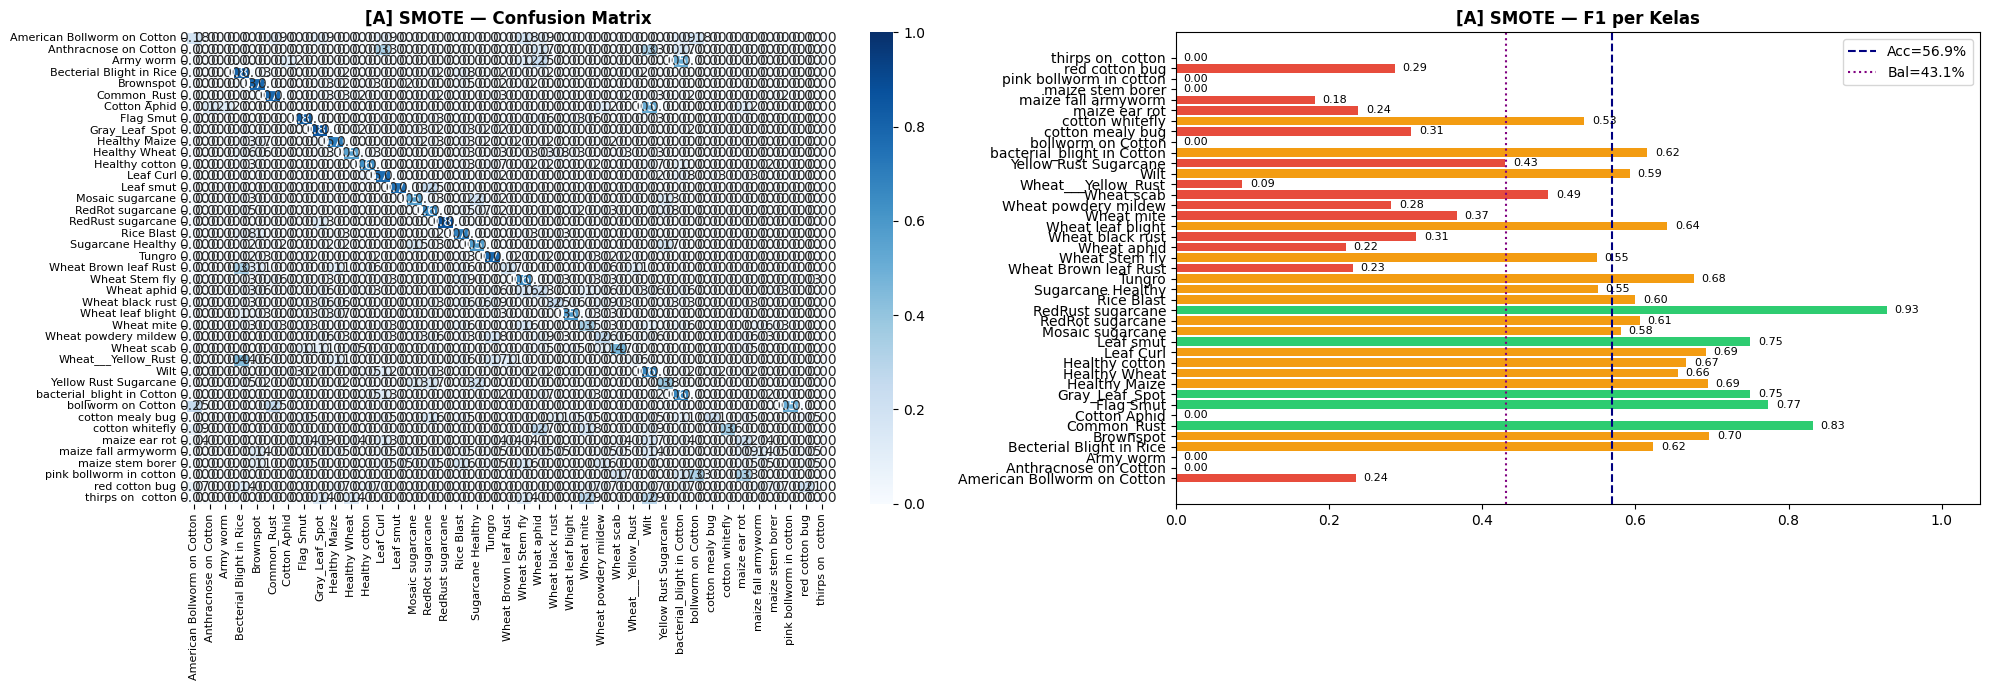

In [ ]:
# Evaluasi A
model_a      = gs_a.best_estimator_
cv_a         = cross_val_score(model_a, X_tr_a_p, y_tr_a, cv=5,
                                scoring='balanced_accuracy', n_jobs=-1)
y_pred_a     = model_a.predict(X_te_a_p)
acc_a        = accuracy_score(y_te_a, y_pred_a)
bal_a        = balanced_accuracy_score(y_te_a, y_pred_a)
cls_a        = np.unique(y_te_a)
rep_a        = classification_report(y_te_a, y_pred_a, labels=cls_a,
                                      target_names=cls_a, output_dict=True)

print(f"\n{'='*55}")
print(f"  [A] Accuracy       : {acc_a*100:.2f}%")
print(f"  [A] Balanced Acc   : {bal_a*100:.2f}%")
print(f"  [A] F1 Macro       : {rep_a['macro avg']['f1-score']*100:.2f}%")
print(f"  [A] CV ±std        : {cv_a.mean()*100:.2f}% ± {cv_a.std()*100:.2f}%")
print(f"{'='*55}")
print(classification_report(y_te_a, y_pred_a, labels=cls_a, target_names=cls_a))

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
cm_a = confusion_matrix(y_te_a, y_pred_a, labels=cls_a, normalize='true')
sns.heatmap(cm_a, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=cls_a, yticklabels=cls_a, ax=axes[0],
            linewidths=0.4, vmin=0, vmax=1)
axes[0].set_title('[A] SMOTE — Confusion Matrix', fontweight='bold')
axes[0].tick_params(axis='x', rotation=90, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

f1_a = [rep_a[c]['f1-score'] for c in cls_a if c in rep_a]
colors = ['#2ecc71' if f >= 0.7 else '#e74c3c' if f < 0.5 else '#f39c12' for f in f1_a]
axes[1].barh(cls_a, f1_a, color=colors)
axes[1].axvline(acc_a, color='navy', linestyle='--', label=f'Acc={acc_a*100:.1f}%')
axes[1].axvline(bal_a, color='purple', linestyle=':', label=f'Bal={bal_a*100:.1f}%')
axes[1].set_xlim(0, 1.05)
axes[1].set_title('[A] SMOTE — F1 per Kelas', fontweight='bold')
axes[1].legend()
for i, v in enumerate(f1_a):
    axes[1].text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('eval_A_smote.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Eksperimen B — Image Augmentation

Augmentasi membuat gambar baru dengan transformasi visual (flip, rotate, brightness, dll.)  
Dilakukan **sebelum** ekstraksi fitur, sehingga fitur yang diekstrak lebih beragam secara visual.


In [ ]:
print("=" * 55)
print("  EKSPERIMEN B — IMAGE AUGMENTATION")
print("=" * 55)

def _aug_and_extract(img_rgb, seed, img_size):
    """Augmentasi satu gambar lalu ekstrak fiturnya."""
    try:
        aug_img = augment(img_rgb, seed=seed)
        r = preprocess_image(aug_img, img_size)
        if r is None:
            return None
        return extract_features(*r)
    except Exception:
        return None


X_b = list(X_orig.copy())
y_b = list(y_orig.copy())

print("🔄 Augmentasi kelas minoritas...")
t0 = time.time()

for cls in class_names:
    current = sum(1 for l in y_b if l == cls)
    needed  = CONFIG['AUG_TARGET'] - current
    if needed <= 0:
        continue

    src = orig_imgs_per_cls[cls]
    if not src:
        continue

    print(f"   {cls[:30]:30s}: {current} → {CONFIG['AUG_TARGET']} (+{needed})")
    tasks = [(src[i % len(src)], CONFIG['RANDOM_STATE'] + i*7 + hash(cls)%999)
             for i in range(needed)]

    aug_feats = Parallel(n_jobs=-1, backend='loky')(
        delayed(_aug_and_extract)(img, seed, CONFIG['IMG_SIZE'])
        for img, seed in tasks
    )
    for f in aug_feats:
        if f is not None:
            X_b.append(f); y_b.append(cls)

X_b = np.nan_to_num(np.array(X_b, dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0)
y_b = np.array(y_b)
print(f"\n✅ Selesai dalam {time.time()-t0:.1f}s")
print(f"📐 Shape X: {X_b.shape}")

# Split
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_b, y_b, test_size=CONFIG['TEST_SIZE'],
    random_state=CONFIG['RANDOM_STATE'], stratify=y_b
)

# Normalisasi
sc_b     = StandardScaler()
X_tr_b_s = sc_b.fit_transform(X_tr_b)
X_te_b_s = sc_b.transform(X_te_b)
print("ℹ️  SMOTE tidak digunakan")

# PCA — pakai N_PCA_95 yang sama dengan Eksperimen A
pca_b    = PCA(n_components=N_PCA_95, random_state=CONFIG['RANDOM_STATE'])
X_tr_b_p = pca_b.fit_transform(X_tr_b_s)
X_te_b_p = pca_b.transform(X_te_b_s)
print(f"PCA: {N_PCA_95} komponen → {pca_b.explained_variance_ratio_.cumsum()[-1]*100:.1f}% variansi")

# GridSearchCV
gs_b = GridSearchCV(SVC(probability=False, random_state=CONFIG['RANDOM_STATE']),
                    param_grid, cv=cv5, scoring='balanced_accuracy', n_jobs=-1, verbose=1)
print("\n🔍 GridSearchCV...")
t0 = time.time()
gs_b.fit(X_tr_b_p, y_tr_b)
print(f"Selesai {time.time()-t0:.1f}s  |  Best: {gs_b.best_params_}")
print(f"CV Balanced Acc: {gs_b.best_score_*100:.2f}%")


  EKSPERIMEN B — IMAGE AUGMENTATION
🔄 Augmentasi kelas minoritas...
   American Bollworm on Cotton   : 56 → 300 (+244)
   Anthracnose on Cotton         : 29 → 300 (+271)
   Army worm                     : 40 → 300 (+260)
   Cotton Aphid                  : 39 → 300 (+261)
   Flag Smut                     : 179 → 300 (+121)
   Healthy Wheat                 : 180 → 300 (+120)
   Leaf smut                     : 40 → 300 (+260)
   RedRust sugarcane             : 75 → 300 (+225)
   Wheat Brown leaf Rust         : 90 → 300 (+210)
   Wheat Stem fly                : 172 → 300 (+128)
   Wheat aphid                   : 156 → 300 (+144)
   Wheat black rust              : 161 → 300 (+139)
   Wheat leaf blight             : 143 → 300 (+157)
   Wheat mite                    : 154 → 300 (+146)
   Wheat powdery mildew          : 169 → 300 (+131)
   Wheat scab                    : 95 → 300 (+205)
   Wheat___Yellow_Rust           : 92 → 300 (+208)
   bollrot on Cotton             : 2 → 300 (+298)
   boll


  [B] Accuracy       : 74.68%
  [B] Balanced Acc   : 74.68%
  [B] F1 Macro       : 74.91%
  [B] CV ±std        : 72.08% ± 1.11%
                             precision    recall  f1-score   support

American Bollworm on Cotton       0.78      0.63      0.70        60
      Anthracnose on Cotton       0.98      0.88      0.93        60
                  Army worm       0.96      0.87      0.91        60
   Becterial Blight in Rice       0.59      0.63      0.61        60
                  Brownspot       0.75      0.73      0.74        60
                Common_Rust       0.92      0.90      0.91        60
               Cotton Aphid       0.96      0.90      0.93        60
                  Flag Smut       0.83      0.82      0.82        60
             Gray_Leaf_Spot       0.66      0.75      0.70        60
              Healthy Maize       0.67      0.63      0.65        60
              Healthy Wheat       0.85      0.73      0.79        60
             Healthy cotton       0.72    

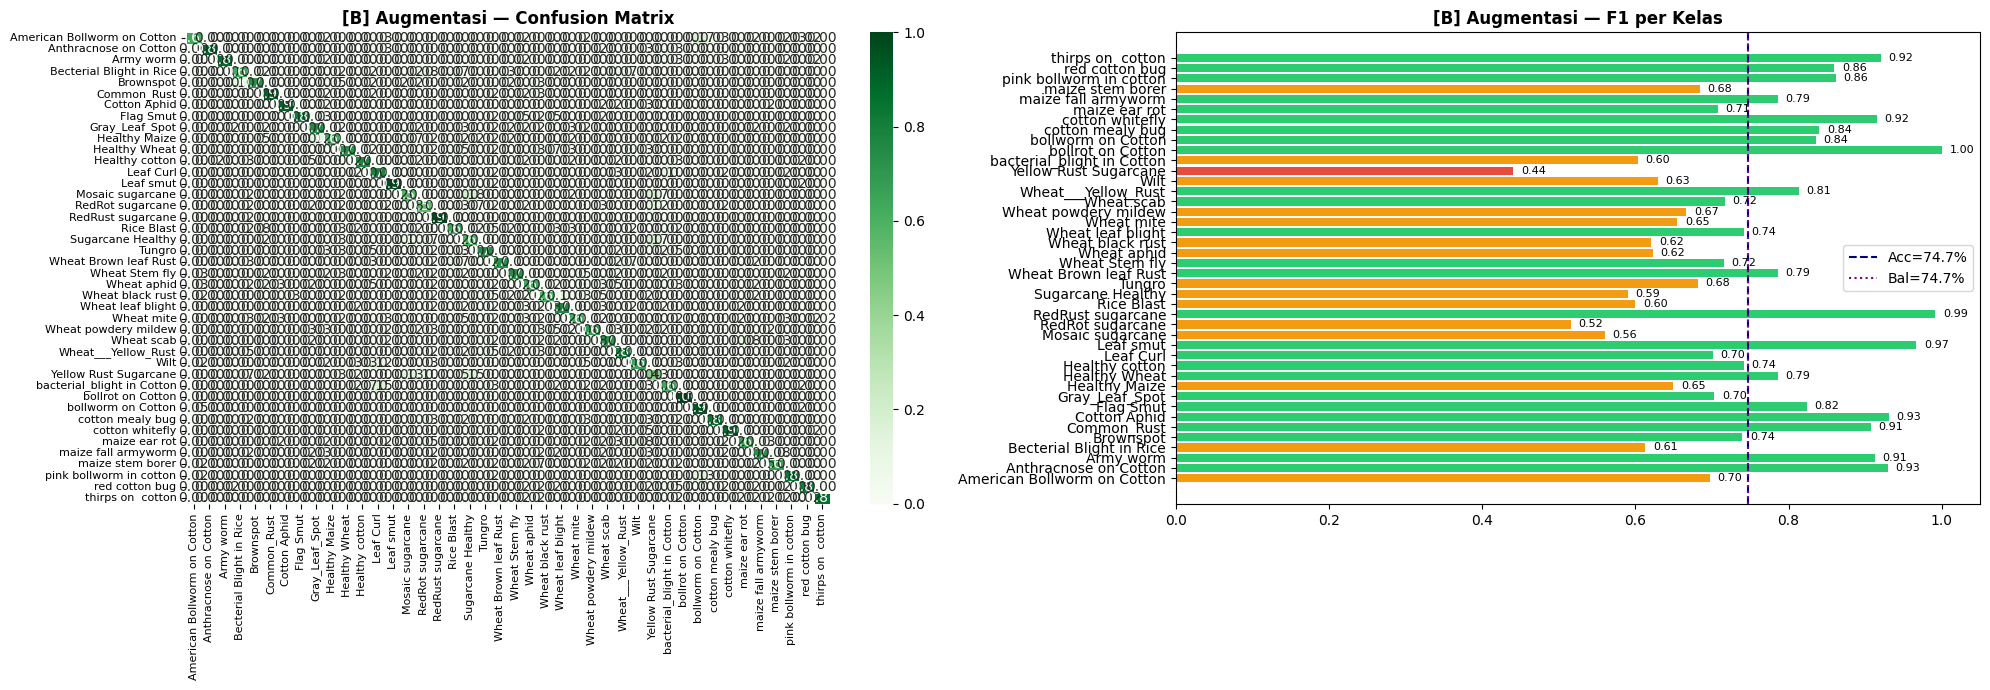

In [ ]:
# Evaluasi B
model_b  = gs_b.best_estimator_
cv_b     = cross_val_score(model_b, X_tr_b_p, y_tr_b, cv=5,
                            scoring='balanced_accuracy', n_jobs=-1)
y_pred_b = model_b.predict(X_te_b_p)
acc_b    = accuracy_score(y_te_b, y_pred_b)
bal_b    = balanced_accuracy_score(y_te_b, y_pred_b)
cls_b    = np.unique(y_te_b)
rep_b    = classification_report(y_te_b, y_pred_b, labels=cls_b,
                                  target_names=cls_b, output_dict=True)

print(f"\n{'='*55}")
print(f"  [B] Accuracy       : {acc_b*100:.2f}%")
print(f"  [B] Balanced Acc   : {bal_b*100:.2f}%")
print(f"  [B] F1 Macro       : {rep_b['macro avg']['f1-score']*100:.2f}%")
print(f"  [B] CV ±std        : {cv_b.mean()*100:.2f}% ± {cv_b.std()*100:.2f}%")
print(f"{'='*55}")
print(classification_report(y_te_b, y_pred_b, labels=cls_b, target_names=cls_b))

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
cm_b = confusion_matrix(y_te_b, y_pred_b, labels=cls_b, normalize='true')
sns.heatmap(cm_b, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=cls_b, yticklabels=cls_b, ax=axes[0],
            linewidths=0.4, vmin=0, vmax=1)
axes[0].set_title('[B] Augmentasi — Confusion Matrix', fontweight='bold')
axes[0].tick_params(axis='x', rotation=90, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

f1_b = [rep_b[c]['f1-score'] for c in cls_b if c in rep_b]
colors = ['#2ecc71' if f >= 0.7 else '#e74c3c' if f < 0.5 else '#f39c12' for f in f1_b]
axes[1].barh(cls_b, f1_b, color=colors)
axes[1].axvline(acc_b, color='navy', linestyle='--', label=f'Acc={acc_b*100:.1f}%')
axes[1].axvline(bal_b, color='purple', linestyle=':', label=f'Bal={bal_b*100:.1f}%')
axes[1].set_xlim(0, 1.05)
axes[1].set_title('[B] Augmentasi — F1 per Kelas', fontweight='bold')
axes[1].legend()
for i, v in enumerate(f1_b):
    axes[1].text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('eval_B_aug.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Perbandingan Akhir: SMOTE vs Augmentasi



📊 TABEL PERBANDINGAN
             Metrik  SMOTE  Augmentasi  Selisih Lebih Baik
       Accuracy (%)  56.90       74.68    17.78      ✅ Aug
   Balanced Acc (%)  43.07       74.68    31.61      ✅ Aug
       F1 Macro (%)  43.11       74.91    31.80      ✅ Aug
Precision Macro (%)  45.97       75.51    29.54      ✅ Aug
   Recall Macro (%)  43.07       74.68    31.61      ✅ Aug
    F1 Weighted (%)  54.73       74.91    20.18      ✅ Aug
        CV Mean (%)  83.22       72.08   -11.14    ✅ SMOTE
         CV Std (%)   3.66        1.11    -2.55      ✅ Aug


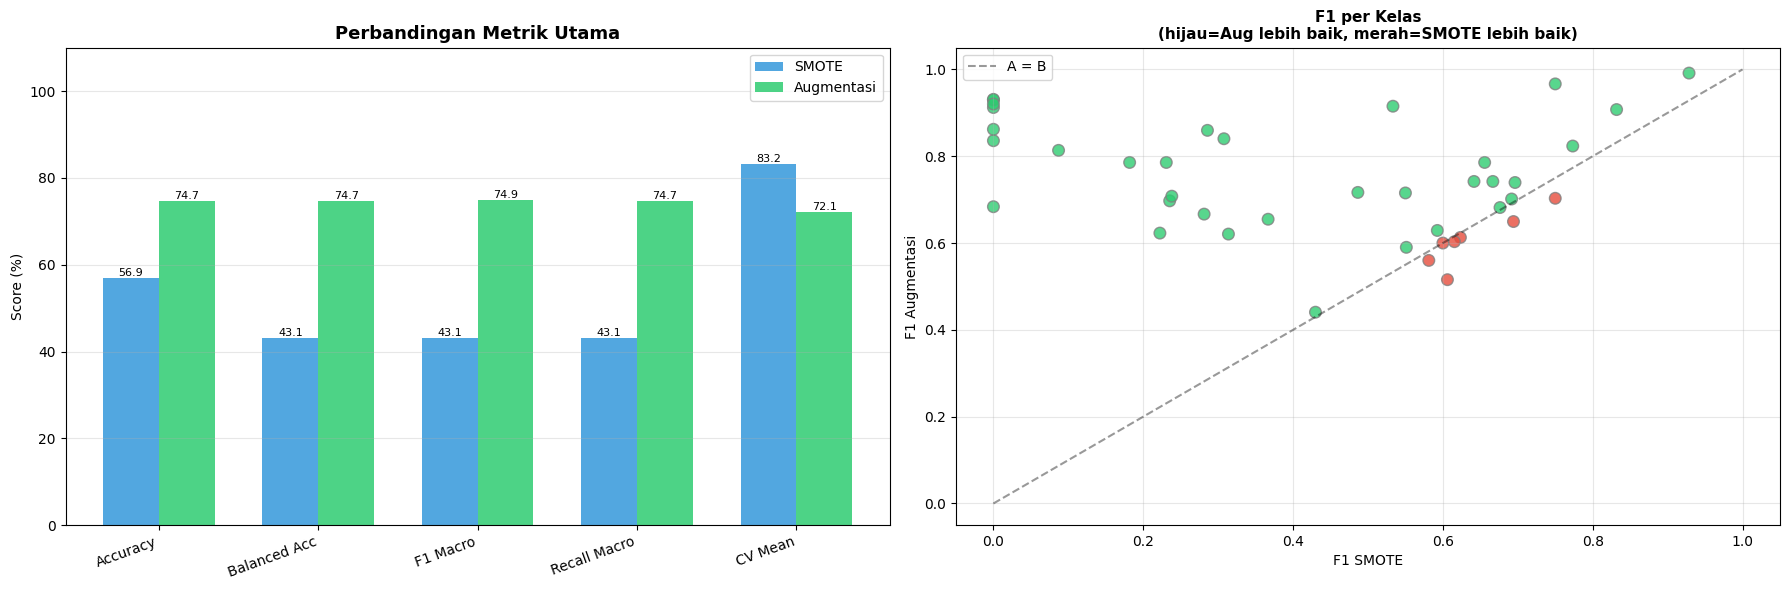


📌 KESIMPULAN
  Accuracy tertinggi    : Augmentasi (74.68%)
  Balanced Acc tertinggi: Augmentasi (74.68%)
  F1 Macro tertinggi    : Augmentasi  (74.91%)

  🏆 METODE TERBAIK: Augmentasi


In [ ]:
# ── Tabel perbandingan ────────────────────────────────────────
ma, wa = rep_a['macro avg'], rep_a['weighted avg']
mb, wb = rep_b['macro avg'], rep_b['weighted avg']

df_cmp = pd.DataFrame({
    'Metrik': ['Accuracy (%)', 'Balanced Acc (%)', 'F1 Macro (%)',
               'Precision Macro (%)', 'Recall Macro (%)',
               'F1 Weighted (%)', 'CV Mean (%)', 'CV Std (%)'],
    'SMOTE': [round(acc_a*100,2), round(bal_a*100,2),
              round(ma['f1-score']*100,2), round(ma['precision']*100,2),
              round(ma['recall']*100,2), round(wa['f1-score']*100,2),
              round(cv_a.mean()*100,2), round(cv_a.std()*100,2)],
    'Augmentasi': [round(acc_b*100,2), round(bal_b*100,2),
                   round(mb['f1-score']*100,2), round(mb['precision']*100,2),
                   round(mb['recall']*100,2), round(wb['f1-score']*100,2),
                   round(cv_b.mean()*100,2), round(cv_b.std()*100,2)],
})
df_cmp['Selisih'] = (df_cmp['Augmentasi'] - df_cmp['SMOTE']).round(2)
df_cmp['Lebih Baik'] = df_cmp.apply(
    lambda r: '✅ Aug' if (r['Selisih'] > 0 and r['Metrik'] != 'CV Std (%)') or
              (r['Metrik'] == 'CV Std (%)' and r['Augmentasi'] < r['SMOTE'])
              else ('✅ SMOTE' if r['Selisih'] != 0 else '🟰 Sama'), axis=1)

print("\n📊 TABEL PERBANDINGAN")
print("=" * 72)
print(df_cmp.to_string(index=False))
print("=" * 72)

# ── Bar chart ─────────────────────────────────────────────────
metrics_show = ['Accuracy (%)', 'Balanced Acc (%)', 'F1 Macro (%)',
                'Recall Macro (%)', 'CV Mean (%)']
df_bar = df_cmp[df_cmp['Metrik'].isin(metrics_show)]
x, w = np.arange(len(df_bar)), 0.35

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

b1 = axes[0].bar(x - w/2, df_bar['SMOTE'].values, w,
                  label='SMOTE', color='#3498db', alpha=0.85)
b2 = axes[0].bar(x + w/2, df_bar['Augmentasi'].values, w,
                  label='Augmentasi', color='#2ecc71', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.replace(' (%)', '') for m in df_bar['Metrik']],
                         rotation=20, ha='right')
axes[0].set_ylabel('Score (%)')
axes[0].set_title('Perbandingan Metrik Utama', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 110)
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.5,
                 f'{h:.1f}', ha='center', fontsize=8)

# Scatter F1 per kelas
common = [c for c in cls_a if c in rep_b]
fa = [rep_a[c]['f1-score'] for c in common]
fb = [rep_b[c]['f1-score'] for c in common]
sc_colors = ['#2ecc71' if b > a else '#e74c3c' for a, b in zip(fa, fb)]
axes[1].scatter(fa, fb, c=sc_colors, s=70, alpha=0.8, edgecolors='gray')
diag = np.linspace(0, 1, 50)
axes[1].plot(diag, diag, 'k--', alpha=0.4, label='A = B')
axes[1].set_xlabel('F1 SMOTE')
axes[1].set_ylabel('F1 Augmentasi')
axes[1].set_title('F1 per Kelas\n(hijau=Aug lebih baik, merah=SMOTE lebih baik)',
                  fontsize=11, fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('perbandingan.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Kesimpulan ────────────────────────────────────────────────
print("\n📌 KESIMPULAN")
print("=" * 55)
w_acc = 'SMOTE' if acc_a >= acc_b else 'Augmentasi'
w_bal = 'SMOTE' if bal_a >= bal_b else 'Augmentasi'
w_f1  = 'SMOTE' if ma['f1-score'] >= mb['f1-score'] else 'Augmentasi'
print(f"  Accuracy tertinggi    : {w_acc} ({max(acc_a,acc_b)*100:.2f}%)")
print(f"  Balanced Acc tertinggi: {w_bal} ({max(bal_a,bal_b)*100:.2f}%)")
print(f"  F1 Macro tertinggi    : {w_f1}  ({max(ma['f1-score'],mb['f1-score'])*100:.2f}%)")
overall = max([w_acc, w_bal, w_f1], key=[w_acc, w_bal, w_f1].count)
print(f"\n  🏆 METODE TERBAIK: {overall}")
print("=" * 55)


## Cell 12 — Simpan Model

In [ ]:
joblib.dump({'model': model_a, 'scaler': sc_a, 'pca': pca_a,
             'class_names': class_names}, 'model_SMOTE.pkl')
joblib.dump({'model': model_b, 'scaler': sc_b, 'pca': pca_b,
             'class_names': class_names}, 'model_AUG.pkl')
print("✅ model_SMOTE.pkl dan model_AUG.pkl tersimpan")


✅ model_SMOTE.pkl dan model_AUG.pkl tersimpan


## Cell 13 — Prediksi Gambar Baru

Saving Image_27.jpg to Image_27.jpg


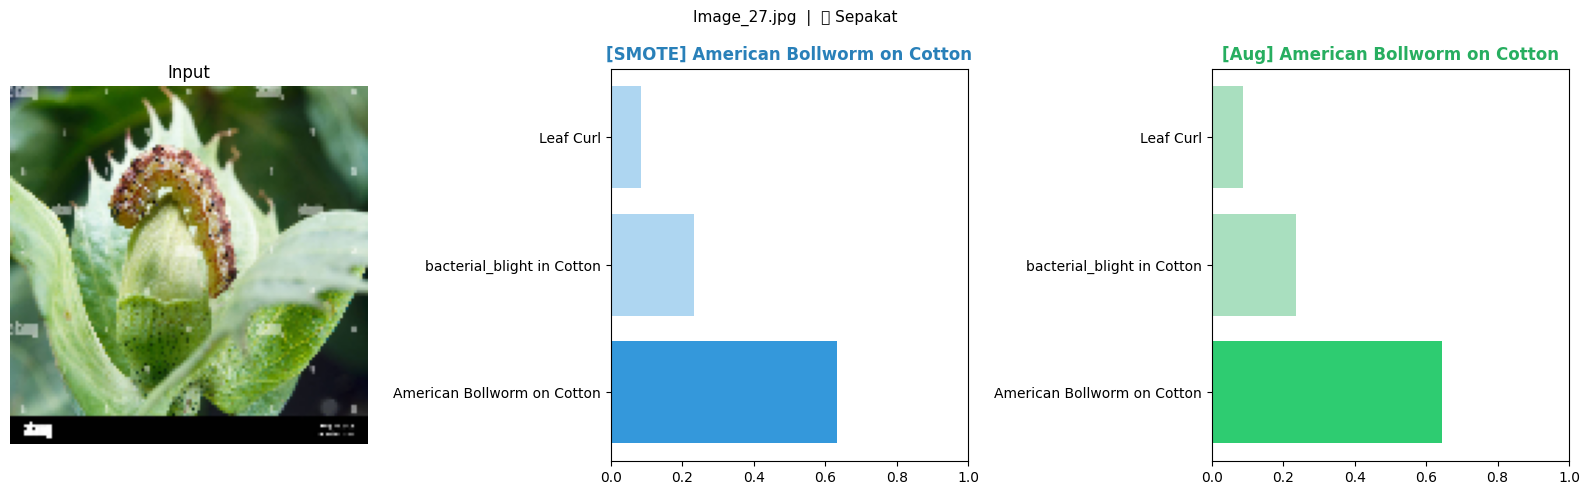

SMOTE → American Bollworm on Cotton  |  Augmentasi → American Bollworm on Cotton  |  ✅ Sepakat


In [ ]:
from google.colab import files

def predict(img_path, bundle):
    r = preprocess_image(img_path, CONFIG['IMG_SIZE'])
    if r is None:
        raise ValueError("Gagal baca gambar")
    feat = extract_features(*r)
    feat = np.nan_to_num(feat.reshape(1, -1))
    feat = bundle['scaler'].transform(feat)
    feat = bundle['pca'].transform(feat)
    pred = bundle['model'].predict(feat)[0]
    dec  = bundle['model'].decision_function(feat)[0]
    exp  = np.exp(dec - dec.max())
    conf = dict(zip(bundle['model'].classes_, exp / exp.sum()))
    return pred, conf, r[0]   # r[0] = img_rgb_orig


bundle_a = joblib.load('model_SMOTE.pkl')
bundle_b = joblib.load('model_AUG.pkl')

uploaded = files.upload()
for fname in uploaded:
    pred_a, conf_a, img_rgb = predict(fname, bundle_a)
    pred_b, conf_b, _       = predict(fname, bundle_b)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    axes[0].imshow(img_rgb); axes[0].set_title("Input"); axes[0].axis('off')

    top3_a = sorted(conf_a.items(), key=lambda x: -x[1])[:3]
    axes[1].barh([c for c,_ in top3_a], [s for _,s in top3_a],
                 color=['#3498db','#aed6f1','#aed6f1'])
    axes[1].set_xlim(0, 1)
    axes[1].set_title(f'[SMOTE] {pred_a}', fontweight='bold', color='#2980b9')

    top3_b = sorted(conf_b.items(), key=lambda x: -x[1])[:3]
    axes[2].barh([c for c,_ in top3_b], [s for _,s in top3_b],
                 color=['#2ecc71','#a9dfbf','#a9dfbf'])
    axes[2].set_xlim(0, 1)
    axes[2].set_title(f'[Aug] {pred_b}', fontweight='bold', color='#27ae60')

    agree = '✅ Sepakat' if pred_a == pred_b else '⚠️ Berbeda'
    plt.suptitle(f'{fname}  |  {agree}', fontsize=11)
    plt.tight_layout(); plt.show()
    print(f"SMOTE → {pred_a}  |  Augmentasi → {pred_b}  |  {agree}")
